# Gobernanza

Por: Daning Montaño

# Librerías

In [1]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 


# Carga de datos

In [2]:
Asambleas_0 = read.csv("../Data/Asambleas.csv")
Asambleas_0$Fecha = as.Date(Asambleas_0$Fecha, format = "%Y-%m-%d")
Mingas_0 = read.csv("../Data/Mingas.csv")
Mingas_0$Fecha = as.Date(Mingas_0$Fecha, format = "%Y-%m-%d")
Capacitaciones = read.csv("../Data/Capacitaciones.csv")
Capacitaciones$Fecha = as.Date(Capacitaciones$Fecha, format = "%Y-%m-%d")

# Análisis de datos

## Registros Gobernanza

### Por comunidad

In [3]:


# 1. Contamos las frecuencias en cada dataset
conteo_asambleas <- Asambleas_0 %>% 
  count(Comunidad, name = "Total_Asambleas")

conteo_mingas <- Mingas_0 %>% 
  count(Comunidad, name = "Total_Mingas")

conteo_capacitaciones <- Capacitaciones %>% 
  count(Comunidad, name = "Total_Capacitaciones")

# 2. Unimos los conteos usando full_join para no perder ninguna comunidad
# y reemplazamos los NA (donde no hubo actividad) por 0
resumen_comunidades <- conteo_asambleas %>%
  full_join(conteo_mingas, by = "Comunidad") %>%
  full_join(conteo_capacitaciones, by = "Comunidad") %>%
  mutate(across(starts_with("Total"), ~replace_na(., 0)))
#resumen_comunidades$Total_actividades = resumen_comunidades$Total_Asambleas + resumen_comunidades$Total_Mingas + resumen_comunidades$Total_Capacitaciones
# Ver el resultado
print(resumen_comunidades)

    Comunidad Total_Asambleas Total_Mingas Total_Capacitaciones
1     Napurak               7           19                    0
2 Sharamentsa              24          163                   52
3  Shuinmamus               1            7                    0
4  Wayusentsa              24           72                    3


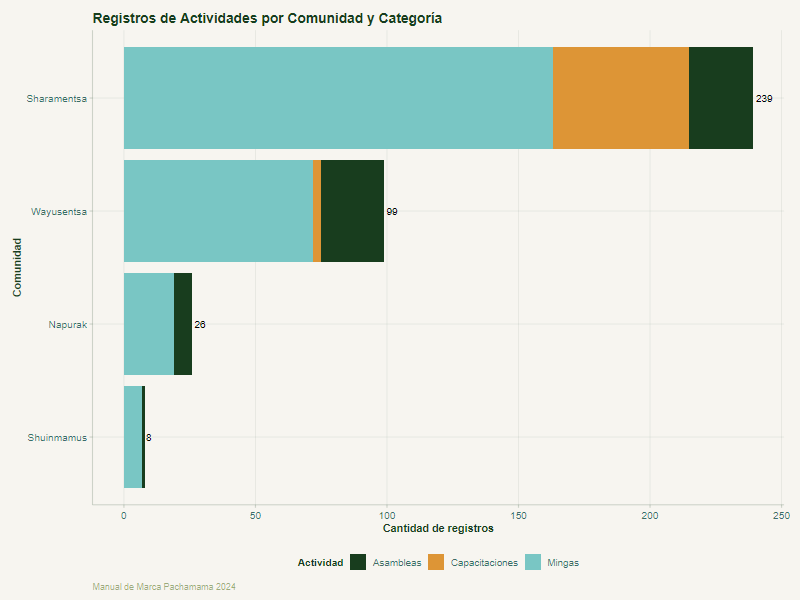

In [4]:
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Aseguramos que el formato 'long' sea correcto
conteo_long <- resumen_comunidades %>%
  # Pasamos de ancho a largo. 'Cantidad' se crea aquí explícitamente.
  pivot_longer(
    cols = starts_with("Total"), 
    names_to = "Actividad", 
    values_to = "Cantidad" 
  ) %>%
  mutate(Actividad = gsub("Total_", "", Actividad)) %>%
  rename(Comunidad = Comunidad) # Aseguramos 'Comunidad' con C mayúscula

# 2. Ahora sí preparamos el conteo para la gráfica
conteo_grafico <- conteo_long %>%
  group_by(Comunidad) %>%
  mutate(Total_Comunidad = sum(Cantidad, na.rm = TRUE)) %>% # Suma segura
  ungroup()

# 3. Gráfica corregida
ggplot(conteo_grafico, aes(x = reorder(Comunidad, Cantidad, sum), y = Cantidad, fill = Actividad)) +
  geom_col() + 
  geom_text(
    aes(y = Total_Comunidad, label = Total_Comunidad),
    hjust = -0.2,            
    size = 3.5,              
    color = "black",         
    check_overlap = TRUE,    
    data = subset(conteo_grafico, !duplicated(Comunidad)) 
  ) +
  coord_flip(clip = "off") + 
  scale_fill_pacha() + 
  labs(
    title = "Registros de Actividades por Comunidad y Categoría",
    x = "Comunidad",
    y = "Cantidad de registros",
    fill = "Actividad",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() + 
  theme(
    text = element_text(family = "sans"),
    legend.position = "bottom"
  )

## Mingas

### Serie de tiempo

In [5]:
# 1. Filtrar y preparar datos de Mingas por Comunidad y Mes
mingas_comunidad_mes <- Mingas_0 %>%
  # Agrupamos por Comunidad (asegúrate que la 'C' coincida con tu CSV) y mes
  mutate(Mes = floor_date(Fecha, "month")) %>%
  group_by(Mes, Comunidad) %>%
  summarise(Total = n(), .groups = 'drop') %>%
  # Pasamos las comunidades a columnas
  pivot_wider(names_from = Comunidad, values_from = Total, values_fill = 0) %>%
  arrange(Mes)

# 2. Convertir a objeto xts
# Quitamos la primera columna (Mes) para los datos y la usamos como índice
don_pacha_mingas <- xts(mingas_comunidad_mes[,-1], order.by = mingas_comunidad_mes$Mes)

# --- CORRECCIÓN DEL ERROR DE COLORES ---
# Usamos ncol(don_pacha_mingas) porque es el objeto que realmente contiene los datos
colores_pacha <- as.character(PAL_CUAL[1:ncol(don_pacha_mingas)])
# ---------------------------------------

# 3. Generar la serie de tiempo interactiva
plot_mingas_comunidad <- dygraph(don_pacha_mingas, main = "Tendencia Mensual de Mingas por Comunidad") %>%
  dyOptions(
    labelsUTC = FALSE, 
    fillGraph = TRUE, 
    fillAlpha = 0.05, 
    drawGrid = TRUE, 
    gridLineColor = "#183d1e20", 
    colors = colores_pacha,       
    strokeWidth = 2,
    axisLineColor = "#3c6d67",
    axisLabelFontSize = 12
  ) %>%
  dyRangeSelector(height = 40, strokeColor = PAL$rio, fillColor = PAL$cielo) %>%
  dyCrosshair(direction = "vertical") %>%
  dyHighlight(
    highlightCircleSize = 5, 
    highlightSeriesBackgroundAlpha = 0.3, 
    hideOnMouseOut = FALSE,
    highlightSeriesOpts = list(strokeWidth = 3)
  ) %>%
  dyRoller(rollPeriod = 1) %>%
  dyAxis("y", label = "Número de Mingas") %>%
  dyLegend(width = 400, show = "always", hideOnMouseOut = TRUE)

# Visualizar


# Visualizar
# Guardar como HTML interactivo
saveWidget(plot_mingas_comunidad, "Plots/Serie_Temporal_Interactivo_Pachamama_mingas.html", selfcontained = TRUE)

### Número de personas en la minga

Warning messages:
1: Removed 180 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
2: Removed 180 rows containing missing values or values outside the scale range
(`geom_point()`). 


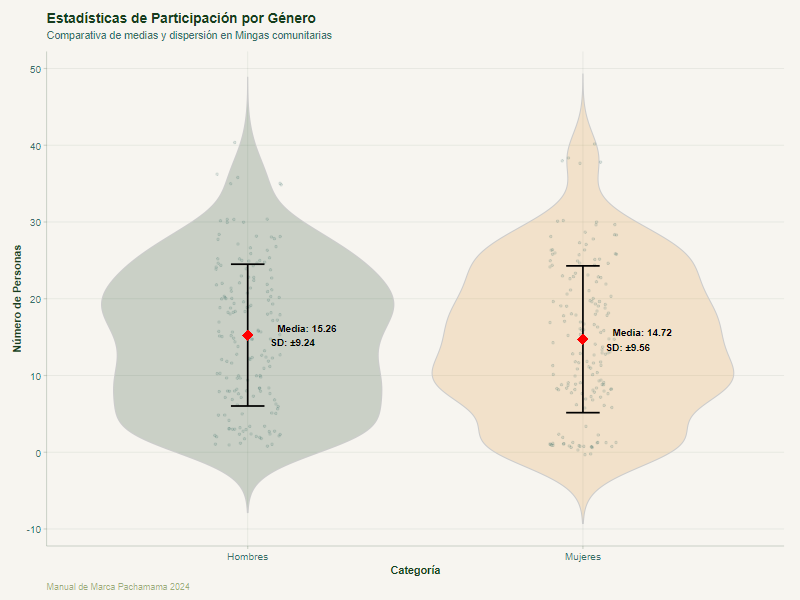

In [14]:

# 1. Pre-procesamiento de datos y cálculo de estadísticos
resumen_stats <- Mingas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad, na.rm = TRUE),
    SD = sd(Cantidad, na.rm = TRUE),
    .groups = 'drop'
  )

mingas_long <- Mingas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 2. Gráfica de Violín con Puntos, Métricas y Etiquetas de Texto
ggplot(mingas_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín
  geom_violin(alpha = 0.2, color = "gray80", trim = FALSE) +
  
  # Puntos individuales (dispersión real)
  geom_point(position = position_jitter(width = 0.1), alpha = 0.15, color = "#3c6d67", size = 1) +
  
  # Barra de Desviación Estándar
  geom_errorbar(data = resumen_stats, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.8) +
  
  # Punto del Promedio (Rombo)
  geom_point(data = resumen_stats, aes(y = Media), 
             shape = 18, size = 5, color = "red") +
  
  # --- NUEVA CAPA: Etiquetas de texto con los valores ---
  geom_text(data = resumen_stats, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.5,      # Desplaza el texto a la derecha de la métrica
            vjust = 0.5,       # Centra verticalmente respecto al punto
            size = 3.5, 
            fontface = "bold",
            color = "black") +
  
  scale_fill_pacha() +
  labs(
    title = "Estadísticas de Participación por Género",
    subtitle = "Comparativa de medias y dispersión en Mingas comunitarias",
    x = "Categoría",
    y = "Número de Personas",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")


### Trabajo hora x persona

In [20]:
Mingas_0$Hora_persona_mujer = Mingas_0$Numero_mujeres * Mingas_0$Numero_horas_minga
Mingas_0$Hora_persona_hombre = Mingas_0$Numero_hombres * Mingas_0$Numero_horas_minga
# 1. Cálculo de Horas-Persona y preparación de datos mensuales


# 1. Preparar los datos de Horas-Persona
mingas_interactivas_df <- Mingas_0 %>%
  mutate(
    # Aplicamos tus fórmulas
    HP_Mujer = Numero_mujeres * Numero_horas_minga,
    HP_Hombre = Numero_hombres * Numero_horas_minga,
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes) %>%
  summarise(
    Horas_Mujeres = sum(HP_Mujer, na.rm = TRUE),
    Horas_Hombres = sum(HP_Hombre, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(Mes)

# 2. Convertir a objeto xts (necesario para dygraphs)
don_pacha_hp <- xts(mingas_interactivas_df[,-1], order.by = mingas_interactivas_df$Mes)

# 3. Definir colores (Asegúrate que PAL_CUAL tenga al menos 2 colores)
colores_hp <- as.character(PAL_CUAL[1:ncol(don_pacha_hp)])

# 4. Generar la serie de tiempo interactiva
plot_hp_genero <- dygraph(don_pacha_hp, main = "Esfuerzo Mensual: Horas-Persona por Género") %>%
  dyOptions(
    labelsUTC = FALSE, 
    fillGraph = TRUE, 
    fillAlpha = 0.1, 
    drawGrid = TRUE, 
    gridLineColor = "#183d1e20", 
    colors = colores_hp,       
    strokeWidth = 2,
    axisLineColor = "#3c6d67",
    axisLabelFontSize = 12
  ) %>%
  dyRangeSelector(height = 40, strokeColor = PAL$rio, fillColor = PAL$cielo) %>%
  dyCrosshair(direction = "vertical") %>%
  dyHighlight(
    highlightCircleSize = 5, 
    highlightSeriesBackgroundAlpha = 0.3, 
    hideOnMouseOut = FALSE,
    highlightSeriesOpts = list(strokeWidth = 3)
  ) %>%
  dyRoller(rollPeriod = 1) %>% # Permite suavizar la curva si hay mucha variación
  dyAxis("y", label = "Total Horas-Persona") %>%
  dyLegend(width = 400, show = "always", hideOnMouseOut = TRUE)

# Visualizar
#plot_hp_genero

saveWidget(plot_hp_genero, "Plots/Serie_Temporal_Interactivo_Pachamama_mingas_esfuerzo.html", selfcontained = TRUE)

In [23]:
unique(Mingas_0$Comunidad)

[1] "Sharamentsa" "Napurak"     "Shuinmamus"  "Wayusentsa" 

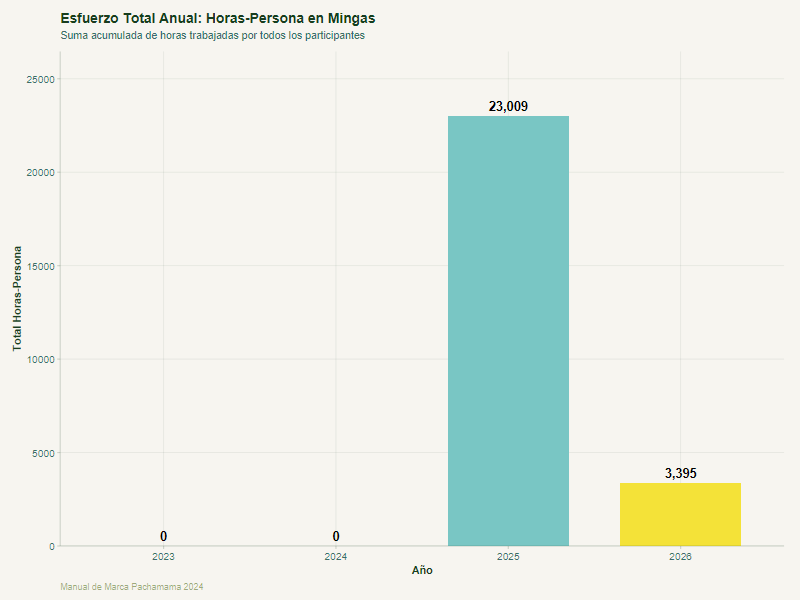

In [34]:

# 1. Preparar los datos anuales
horas_anuales <- Mingas_0 %>%
  #filter(Comunidad == "Wayusentsa")%>%
  mutate(
    # Calculamos horas-persona total por cada fila
    HP_fila = (Numero_mujeres + Numero_hombres) * Numero_horas_minga,
    # Extraemos el año
    Anio = as.factor(year(as.Date(Fecha)))
  ) %>%
  group_by(Anio) %>%
  summarise(Total_HP = sum(HP_fila, na.rm = TRUE), .groups = 'drop')

# 2. Generar el gráfico de barras
ggplot(horas_anuales, aes(x = Anio, y = Total_HP, fill = Anio)) +
  geom_col(width = 0.7, show.legend = FALSE) +
  # Etiquetas sobre las barras para lectura rápida
  geom_text(aes(label = scales::comma(Total_HP)), 
            vjust = -0.5, 
            fontface = "bold", 
            size = 4.5) +
  scale_fill_pacha() + # Colores institucionales
  labs(
    title = "Esfuerzo Total Anual: Horas-Persona en Mingas",
    subtitle = "Suma acumulada de horas trabajadas por todos los participantes",
    x = "Año",
    y = "Total Horas-Persona",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  # Ajustar el límite superior para que no se corte la etiqueta
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

In [35]:
total_valor_trabajo = 9702 * 2.5
total_valor_trabajo

[1] 24255

### Descripción de minga

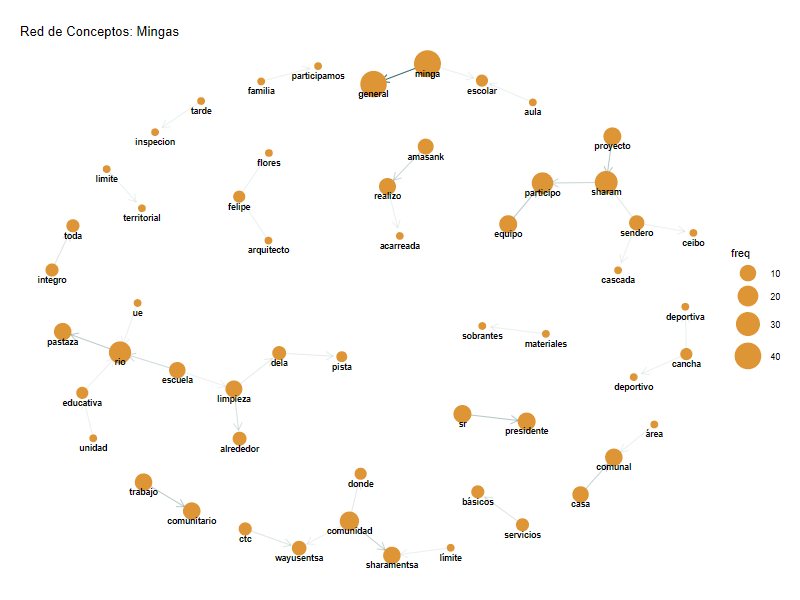

In [38]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Mingas_0 %>%
  filter(!is.na(Actividad_desarrollada_minga)) %>%
  mutate(texto = str_to_lower(Actividad_desarrollada_minga) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Mingas",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

## Asambleas

Deberiamos revisar cuanto tiempo de la asamblea le dedican a conservación

In [41]:
Asambleas_0$Decision_principal

 [1] "Realizo la reunión extra ordinaria con la comunidad."                                                                                                                                                                                                   
 [2] "Asamblea para socialización de la creación de nuevo colegio particular Waldor."                                                                                                                                                                         
 [3] "Asamblea extraordinaria de la comunidad achuar Sharamentsa."                                                                                                                                                                                            
 [4] "Asamblea extraordinaria de la comunidad Achuar Sharamentsa"                                                                                                                                                                          

### Serie de tiempo

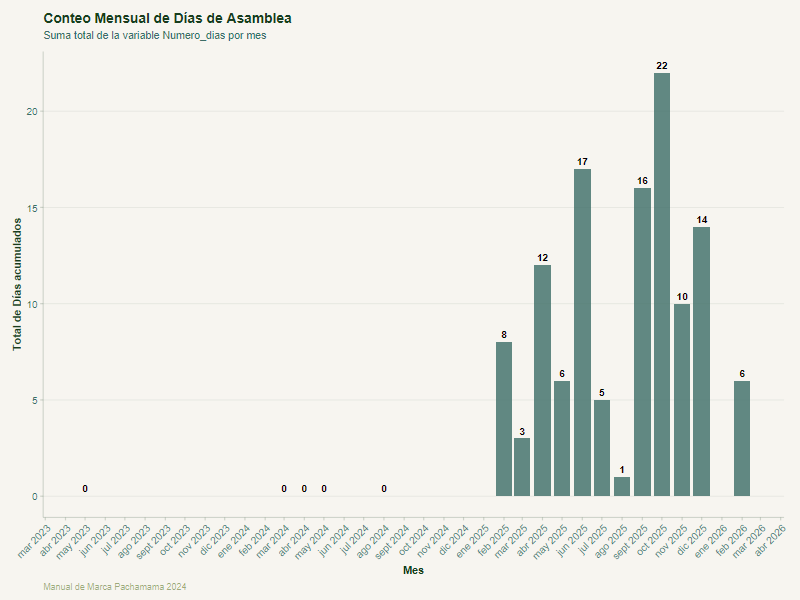

In [43]:

# 1. Preparar los datos: Conteo de Numero_dias por mes
asambleas_mensual <- Asambleas_0 %>%
  mutate(Mes = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes) %>%
  summarise(Total_Dias = sum(Numero_dias, na.rm = TRUE), .groups = 'drop')

# 2. Generar la gráfica de barras mensuales
ggplot(asambleas_mensual, aes(x = Mes, y = Total_Dias)) +
  # Usamos un color sólido de tu paleta institucional
  geom_col(fill = "#3c6d67", alpha = 0.8) + 
  # Etiquetas sobre las barras para ver el conteo exacto
  geom_text(aes(label = Total_Dias), vjust = -0.5, size = 3.5, fontface = "bold") +
  # Escala de fecha para que se lea "Ene 2024", etc.
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Conteo Mensual de Días de Asamblea",
    subtitle = "Suma total de la variable Numero_dias por mes",
    x = "Mes",
    y = "Total de Días acumulados",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), # Inclinamos fechas para legibilidad
    panel.grid.major.x = element_blank()
  )

In [48]:
# 1. Preparar los datos con corrección de NA a 1 para los existentes
asambleas_discontinuas <- Asambleas_0 %>%
  mutate(
    Mes = floor_date(as.Date(Fecha), "month"),
    Dias_Corregidos = replace_na(Numero_dias, 1)
  ) %>%
  group_by(Mes) %>%
  summarise(Total_Dias = sum(Dias_Corregidos, na.rm = TRUE))

# 2. Crear un calendario completo de meses para detectar los huecos
# Esto es vital para que dygraphs sepa dónde NO debe dibujar líneas
rango_fechas <- seq(min(asambleas_discontinuas$Mes), 
                    max(asambleas_discontinuas$Mes), 
                    by = "month")

df_completo <- data.frame(Mes = rango_fechas) %>%
  left_join(asambleas_discontinuas, by = "Mes") 
  # NOTA: No usamos replace_na(0) aquí. Dejamos los Total_Dias como NA 
  # para que dygraphs rompa la línea.

# 3. Convertir a objeto xts
don_pacha_gap <- xts(df_completo$Total_Dias, order.by = df_completo$Mes)
colnames(don_pacha_gap) <- "Dias_Asamblea"

# 4. Generar la serie de tiempo con "puntos sueltos"
plot_asambleas_interactivo = dygraph(don_pacha_gap, main = "Días de Asamblea (Solo meses con actividad)") %>%
  dyOptions(
    labelsUTC = FALSE, 
    drawPoints = TRUE,          # Dibujamos puntos para ver los meses aislados
    pointSize = 4,
    connectSeparatedPoints = FALSE, # ¡ESTA ES LA CLAVE! Evita unir puntos lejanos
    fillGraph = FALSE,          # Quitamos el relleno para que se note la discontinuidad
    colors = "#3c6d67",
    strokeWidth = 2,
    axisLineColor = "#3c6d67"
  ) %>%
  dyRangeSelector(height = 40, strokeColor = PAL$rio, fillColor = PAL$cielo) %>%
  dyAxis("y", label = "Días de Asamblea") %>%
  dyLegend(show = "always")

# Visualizar


saveWidget(plot_asambleas_interactivo, "Plots/Serie_Temporal_Interactivo_Pachamama_asambleas.html", selfcontained = TRUE)

### Participación de personas x minga

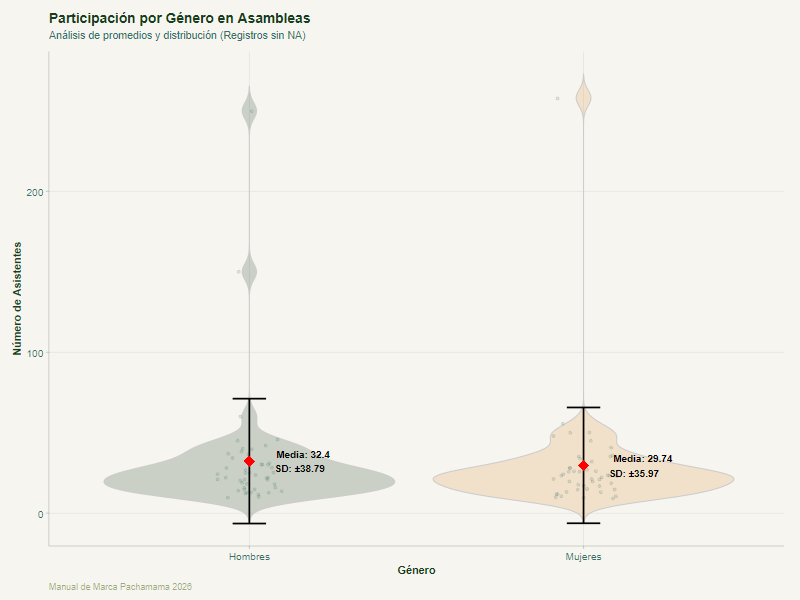

In [50]:
# 1. Pre-procesamiento: Limpieza de NAs y cálculo de estadísticos
# Filtramos primero para que las medias y desviaciones sean precisas
asambleas_limpias <- Asambleas_0 %>%
  select(Numero_hombres, Numero_mujeres) %>%
  drop_na(Numero_hombres, Numero_mujeres) # Eliminamos filas con NA en estas columnas

resumen_stats_asambleas <- asambleas_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad),
    SD = sd(Cantidad),
    .groups = 'drop'
  )

asambleas_long <- asambleas_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 2. Gráfica de Violín con Puntos, Métricas y Etiquetas (Datos de Asambleas)
ggplot(asambleas_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín
  geom_violin(alpha = 0.2, color = "gray80", trim = FALSE) +
  
  # Puntos individuales (dispersión real de asambleas)
  geom_point(position = position_jitter(width = 0.1), alpha = 0.15, color = "#3c6d67", size = 1.2) +
  
  # Barra de Desviación Estándar (±1 SD)
  geom_errorbar(data = resumen_stats_asambleas, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.8) +
  
  # Punto del Promedio (Rombo rojo)
  geom_point(data = resumen_stats_asambleas, aes(y = Media), 
             shape = 18, size = 5, color = "red") +
  
  # Etiquetas de texto con los valores exactos
  geom_text(data = resumen_stats_asambleas, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.5, 
            vjust = 0.5, 
            size = 3.5, 
            fontface = "bold",
            color = "black") +
  
  scale_fill_pacha() + # Usando tu paleta institucional
  labs(
    title = "Participación por Género en Asambleas",
    subtitle = "Análisis de promedios y distribución (Registros sin NA)",
    x = "Género",
    y = "Número de Asistentes",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")

### Tipo de Asamblea

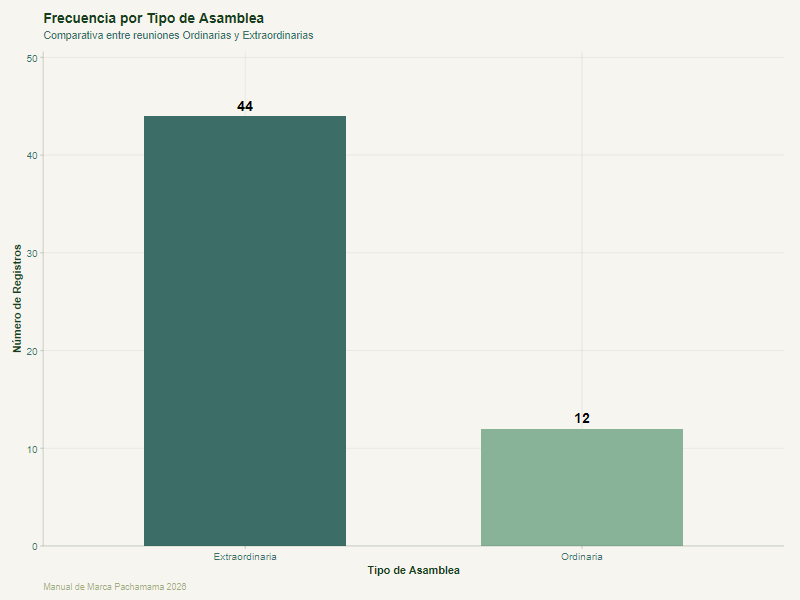

In [53]:

# 1. Preparar los datos: Contar frecuencias
resumen_tipo_asamblea <- Asambleas_0 %>%
  group_by(Tipo_asamblea) %>%
  summarise(Conteo = n(), .groups = 'drop') %>%
  # Limpieza opcional por si hay NAs o vacíos
  filter(!is.na(Tipo_asamblea) & Tipo_asamblea != "")

# 2. Generar la gráfica de barras
ggplot(resumen_tipo_asamblea, aes(x = reorder(Tipo_asamblea, -Conteo), y = Conteo, fill = Tipo_asamblea)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  # Añadir etiquetas de valor sobre las barras
  geom_text(aes(label = Conteo), vjust = -0.5, fontface = "bold", size = 5) +
  # Usar colores institucionales (o manuales si prefieres)
  scale_fill_manual(values = c("Extraordinaria" = "#3c6d67", "Ordinaria" = "#89b399")) +
  labs(
    title = "Frecuencia por Tipo de Asamblea",
    subtitle = "Comparativa entre reuniones Ordinarias y Extraordinarias",
    x = "Tipo de Asamblea",
    y = "Número de Registros",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Ajustar el eje Y para que la etiqueta no se corte
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama()

### Decisión Asamblea

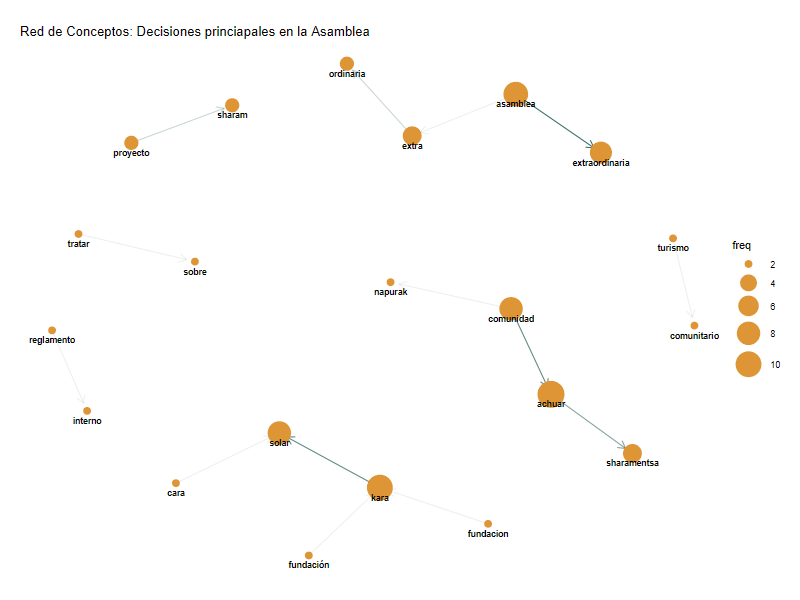

In [56]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Asambleas_0 %>%
  filter(!is.na(Decision_principal)) %>%
  mutate(texto = str_to_lower(Decision_principal) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Decisiones princiapales en la Asamblea",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

## Generación de capacidades

In [63]:
Capacitaciones$Numero_hombres
Capacitaciones$Numero_mujeres

 [1]  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA
[20]  NA  NA  NA  NA  NA  NA  NA   6  16   8   8  12  12   1   1   2   2   4   4
[39]   2   7   4   1   2  NA  NA  NA   2   2   2  10   7  14   0   0 200

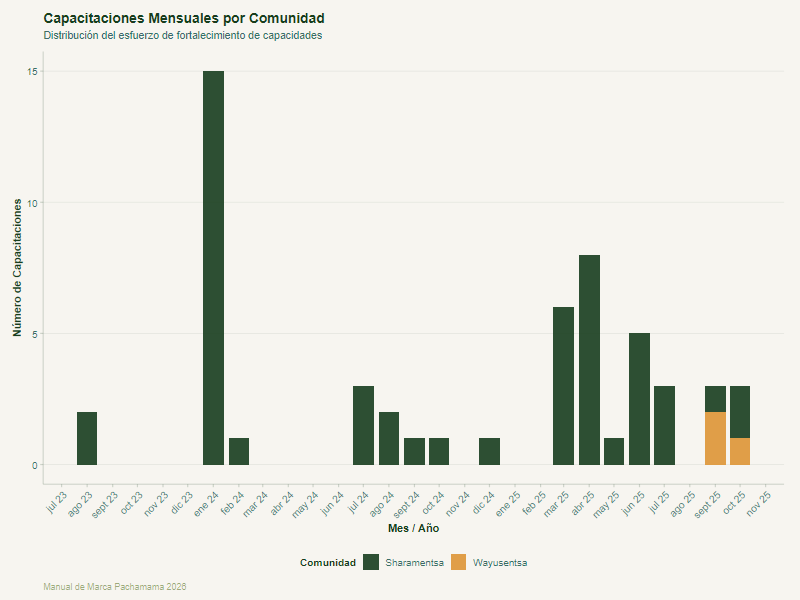

In [60]:
# 1. Preparar los datos: Agrupación mensual por comunidad
capacitaciones_comunidad <- Capacitaciones %>%
  mutate(
    # Aseguramos formato fecha y agrupamos por mes
    Mes = floor_date(as.Date(Fecha), "month"),
    # Limpiamos el nombre de la comunidad si es necesario
    Comunidad = as.factor(Comunidad) 
  ) %>%
  group_by(Mes, Comunidad) %>%
  summarise(Total = n(), .groups = 'drop')

# 2. Generar la gráfica de barras apiladas
ggplot(capacitaciones_comunidad, aes(x = Mes, y = Total, fill = Comunidad)) +
  # Barras apiladas para ver el total y el aporte de cada comunidad
  geom_col(alpha = 0.9, width = 25) + 
  # Colores institucionales (usando tu paleta personalizada)
  scale_fill_pacha() + 
  # Configuración del eje X para que sea legible
  scale_x_date(date_labels = "%b %y", date_breaks = "1 month") +
  labs(
    title = "Capacitaciones Mensuales por Comunidad",
    subtitle = "Distribución del esfuerzo de fortalecimiento de capacidades",
    x = "Mes / Año",
    y = "Número de Capacitaciones",
    fill = "Comunidad",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    panel.grid.major.x = element_blank()
  )

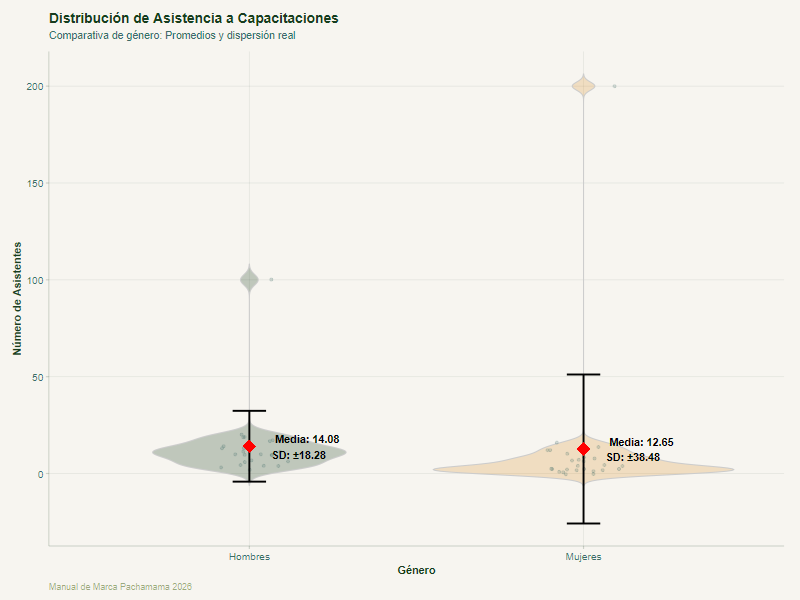

In [64]:

# 1. Pre-procesamiento: Limpieza de NAs y transformación a formato largo
capacitaciones_limpias <- Capacitaciones %>%
  select(Numero_hombres, Numero_mujeres) %>%
  # Eliminamos filas donde ambos campos sean NA para no falsear el violín
  drop_na(Numero_hombres, Numero_mujeres) 

# 2. Cálculo de estadísticos para las etiquetas
resumen_stats_cap <- capacitaciones_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres")) %>%
  group_by(Genero) %>%
  summarise(
    Media = mean(Cantidad),
    SD = sd(Cantidad),
    .groups = 'drop'
  )

# 3. Preparación de datos para la gráfica
cap_long <- capacitaciones_limpias %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Cantidad") %>%
  mutate(Genero = if_else(Genero == "Numero_hombres", "Hombres", "Mujeres"))

# 4. Generación de la gráfica de Violín
ggplot(cap_long, aes(x = Genero, y = Cantidad, fill = Genero)) +
  # Fondo de Violín (Densidad de participación)
  geom_violin(alpha = 0.25, color = "gray80", trim = FALSE) +
  
  # Puntos (Jitter) para ver cada capacitación individual
  geom_point(position = position_jitter(width = 0.12), 
             alpha = 0.2, color = "#3c6d67", size = 1.2) +
  
  # Barra de Desviación Estándar (±1 SD)
  geom_errorbar(data = resumen_stats_cap, 
                aes(y = Media, ymin = Media - SD, ymax = Media + SD), 
                width = 0.1, color = "black", linewidth = 0.9) +
  
  # Punto del Promedio (Rombo Rojo)
  geom_point(data = resumen_stats_cap, aes(y = Media), 
             shape = 18, size = 6, color = "red") +
  
  # Etiquetas de texto con valores redondeados
  geom_text(data = resumen_stats_cap, 
            aes(y = Media, label = paste0("Media: ", round(Media, 2), 
                                          "\nSD: ±", round(SD, 2))),
            hjust = -0.4, vjust = 0.5, size = 3.8, fontface = "bold") +
  
  scale_fill_pacha() + 
  labs(
    title = "Distribución de Asistencia a Capacitaciones",
    subtitle = "Comparativa de género: Promedios y dispersión real",
    x = "Género",
    y = "Número de Asistentes",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(legend.position = "none")

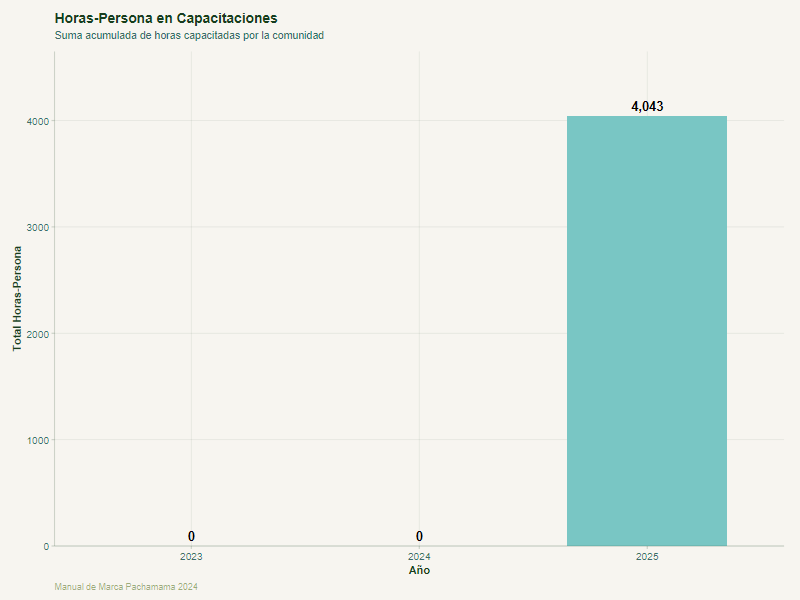

In [67]:
Capacitaciones$Hora_persona_mujer = Capacitaciones$Numero_mujeres * Capacitaciones$Numero_horas_capacitacion
Capacitaciones$Hora_persona_hombre = Capacitaciones$Numero_hombres * Capacitaciones$Numero_horas_capacitacion
# 1. Cálculo de Horas-Persona y preparación de datos mensuales


# 1. Preparar los datos de Horas-Persona
Capacitaciones_df <- Capacitaciones %>%
  mutate(
    # Aplicamos tus fórmulas
    HP_Mujer = Numero_mujeres * Numero_horas_capacitacion,
    HP_Hombre = Numero_hombres * Numero_horas_capacitacion,
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes) %>%
  summarise(
    Horas_Mujeres = sum(HP_Mujer, na.rm = TRUE),
    Horas_Hombres = sum(HP_Hombre, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(Mes)




# 1. Preparar los datos anuales
horas_anuales <- Capacitaciones %>%
  #filter(Comunidad == "Wayusentsa")%>%
  mutate(
    # Calculamos horas-persona total por cada fila
    HP_fila = (Numero_mujeres + Numero_hombres) * Numero_horas_capacitacion,
    # Extraemos el año
    Anio = as.factor(year(as.Date(Fecha)))
  ) %>%
  group_by(Anio) %>%
  summarise(Total_HP = sum(HP_fila, na.rm = TRUE), .groups = 'drop')

# 2. Generar el gráfico de barras
ggplot(horas_anuales, aes(x = Anio, y = Total_HP, fill = Anio)) +
  geom_col(width = 0.7, show.legend = FALSE) +
  # Etiquetas sobre las barras para lectura rápida
  geom_text(aes(label = scales::comma(Total_HP)), 
            vjust = -0.5, 
            fontface = "bold", 
            size = 4.5) +
  scale_fill_pacha() + # Colores institucionales
  labs(
    title = "Horas-Persona en Capacitaciones",
    subtitle = "Suma acumulada de horas capacitadas por la comunidad",
    x = "Año",
    y = "Total Horas-Persona",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  # Ajustar el límite superior para que no se corte la etiqueta
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

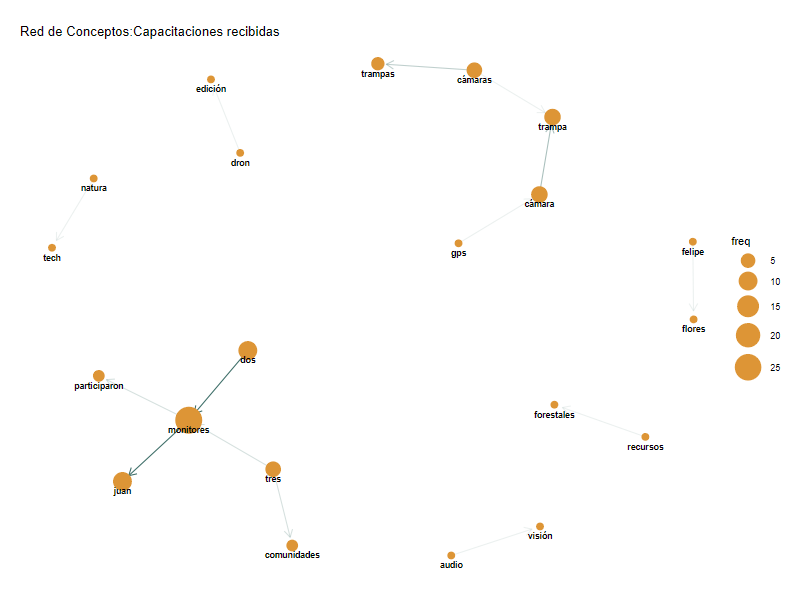

In [69]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- Capacitaciones %>%
  filter(!is.na(Capacidad_adquirida)) %>%
  mutate(texto = str_to_lower(Capacidad_adquirida) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos:Capacitaciones recibidas",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))